Title: RL_data_analysis_NM_KS.ipynb

Purpose: Analyse the distributions from the output from the SEM

Author: Onno Nennecke on 17.04.2025 Modified: 09.04.2026

Input data: 

- Adjusted Model output: model_output_all.nc
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'

Output data:

- Plots: 2D_hist, Return_period_plot
    - These files lie here: /home/onennecke/Code/Figures/

In [ ]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_all.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

ds_CMIP6 = ds.where((ds.ESM_run != 'ERA5_hist_week') & (ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ds_CMIP6.load()

ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
ds_ERA5.load()

ds_SMARD = ds.where(ds.ESM_run == 'SMARD_hist', drop=True)
ds_SMARD.load()
# ts_datasets

<xarray.Dataset> Size: 365kB
Dimensions:        (ESM_run: 1, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 52B 'SMARD'
    run            (ESM_run) <U12 48B 'hist'
  * ESM_run        (ESM_run) <U23 92B 'SMARD_hist'
    country        float64 8B 9.0
    period         (ESM_run) <U4 16B 'wwd'
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 29kB nan nan nan nan ... nan nan nan
    demand         (ESM_run, time) float64 29kB 1.097e+03 ... 1.204e+03
    sfcWind        (ESM_run, time) float64 29kB nan nan nan nan ... nan nan nan
    rsds           (ESM_run, time) float32 15kB nan nan nan nan ... nan nan nan
    tas            (ESM_run, time) float32 15kB nan nan nan nan ... nan nan nan
    tasmax         (ESM_run, time) float32 15kB nan nan nan nan ... nan nan nan
    wind_off_prod  (ESM_run, time) float64 29kB 12.51 10.33 ... 61.19 69.34
    wind_on_prod   (ESM_run, time) float64 29kB 298.8 591.6 ... 534.3 529.0
    solar_prod     (ESM_run, time) float64 29kB 17.08 7.759 ... 22.93 49.09
    total_prod     (ESM_run, time) float64 29kB 328.4 609.7 ... 618.5 647.4
    Netto          (ESM_run, time) float64 29kB nan nan nan nan ... nan nan nan
    Residual_load  (ESM_run, time) float64 29kB 768.5 679.2 ... 659.8 556.8

In [3]:
# Filter for winter months (October to March)
ts_winter = ts_datasets.where(ts_datasets['time.month'].isin([10, 11, 12, 1, 2, 3]), drop=True)

ts_high_RL = ts_datasets.where(ts_datasets['Residual_load'] >= 1319.138650687668, drop=True)

In [4]:
ts_high_RL

<xarray.Dataset> Size: 25MB
Dimensions:        (ESM_run: 193, time: 1529)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 12kB 2015-01-01 ... 2024-12-31
    ESM            (ESM_run) <U13 10kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run            (ESM_run) <U12 9kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2'
  * ESM_run        (ESM_run) <U23 18kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL...
    country        float64 8B 9.0
    period         (ESM_run) <U4 3kB 'week' 'week' 'week' ... 'week' 'week'
    doy            (time) int64 12kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
Data variables:
    temp           (ESM_run, time) float64 2MB nan nan nan ... nan -8.134 -9.41
    demand         (ESM_run, time) float64 2MB nan nan ... 1.62e+03 1.636e+03
    sfcWind        (ESM_run, time) float64 2MB nan nan nan ... nan 3.01 4.735
    rsds           (ESM_run, time) float32 1MB nan nan nan ... nan 38.66 48.7
    tas            (ESM_run, time) float32 1MB nan nan nan ... nan -7.047 -8.388
    tasmax         (ESM_run, time) float32 1MB nan nan nan ... nan -3.341 -4.217
    wind_off_prod  (ESM_run, time) float64 2MB nan nan nan ... nan 9.998 79.37
    wind_on_prod   (ESM_run, time) float64 2MB nan nan nan ... nan 31.44 148.9
    solar_prod     (ESM_run, time) float64 2MB nan nan nan ... nan 71.95 87.86
    total_prod     (ESM_run, time) float64 2MB nan nan nan ... nan 113.4 316.1
    Netto          (ESM_run, time) float64 2MB nan nan ... -1.507e+03 -1.32e+03
    Residual_load  (ESM_run, time) float64 2MB nan nan ... 1.507e+03 1.32e+03

In [5]:
# Calculate a ESM mean 'ESM' (which is a secondary coordinate)
esm_mean = ts_datasets.groupby("ESM").mean(dim="ESM_run")
esm_mean

<xarray.Dataset> Size: 3MB
Dimensions:        (ESM: 11, time: 3650)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
  * time           (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    country        float64 8B 9.0
    doy            (time) int64 29kB 1 2 3 4 5 6 7 ... 360 361 362 363 364 365
  * ESM            (ESM) object 88B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
Data variables:
    temp           (ESM, time) float64 321kB 3.64 2.506 ... 0.2199 -0.01609
    demand         (ESM, time) float64 321kB 1.475e+03 1.489e+03 ... 1.52e+03
    sfcWind        (ESM, time) float64 321kB 8.221 6.835 6.429 ... 5.209 6.2
    rsds           (ESM, time) float32 161kB 14.97 20.64 30.62 ... 27.49 29.43
    tas            (ESM, time) float32 161kB 3.578 2.655 0.7156 ... 0.6361 0.48
    tasmax         (ESM, time) float32 161kB 5.251 4.133 2.302 ... 2.723 2.536
    wind_off_prod  (ESM, time) float64 321kB 158.5 172.5 126.9 ... 87.46 108.4
    wind_on_prod   (ESM, time) float64 321kB 826.7 568.6 452.7 ... 350.5 513.4
    solar_prod     (ESM, time) float64 321kB 23.77 35.51 53.58 ... 50.18 52.75
    total_prod     (ESM, time) float64 321kB 1.009e+03 776.6 ... 488.1 674.5
    Netto          (ESM, time) float64 321kB -465.8 -712.3 ... -1.029e+03 -845.4
    Residual_load  (ESM, time) float64 321kB 465.8 712.3 ... 1.029e+03 845.4

In [6]:
# ts_datasets['temp'].sel(ESM='ACCESS-CM2').values.flatten()
ts_datasets['temp'].where(ts_datasets['ESM'] == 'ACCESS-CM2', drop=True).values.flatten()

array([ 2.86192524, -0.34920193, -2.72152428, ..., -5.93731613,
       -7.32317377, -7.60702088])

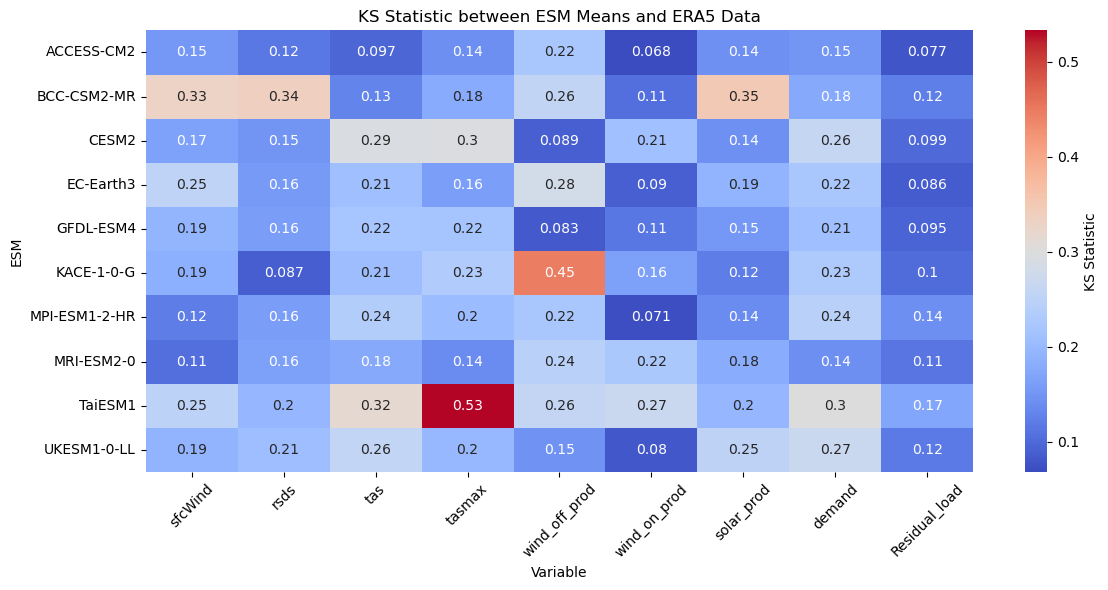

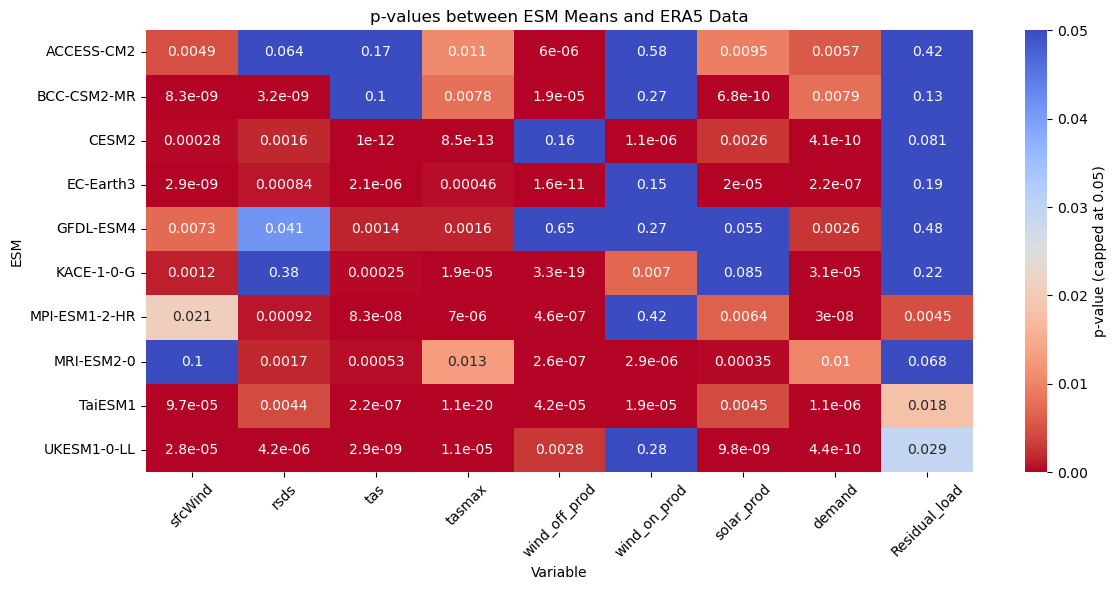

In [18]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(ts_high_RL[var].where(ts_high_RL['ESM'] == esm, drop=True).values.flatten()[~np.isnan(ts_high_RL[var].where(ts_high_RL['ESM'] == esm, drop=True).values.flatten())], ts_high_RL[var].where(ts_high_RL['ESM'] == 'ERA5_week', drop=True).values.flatten()[~np.isnan(ts_high_RL[var].where(ts_high_RL['ESM'] == 'ERA5_week', drop=True).values.flatten())])
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'demand', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

p_thresh = 0.05

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

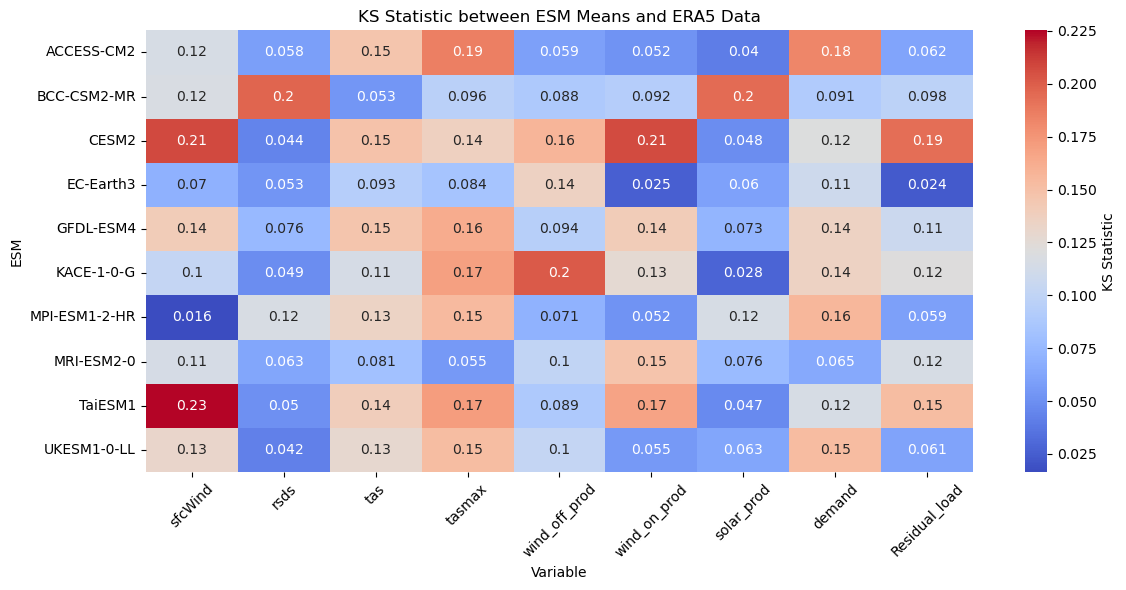

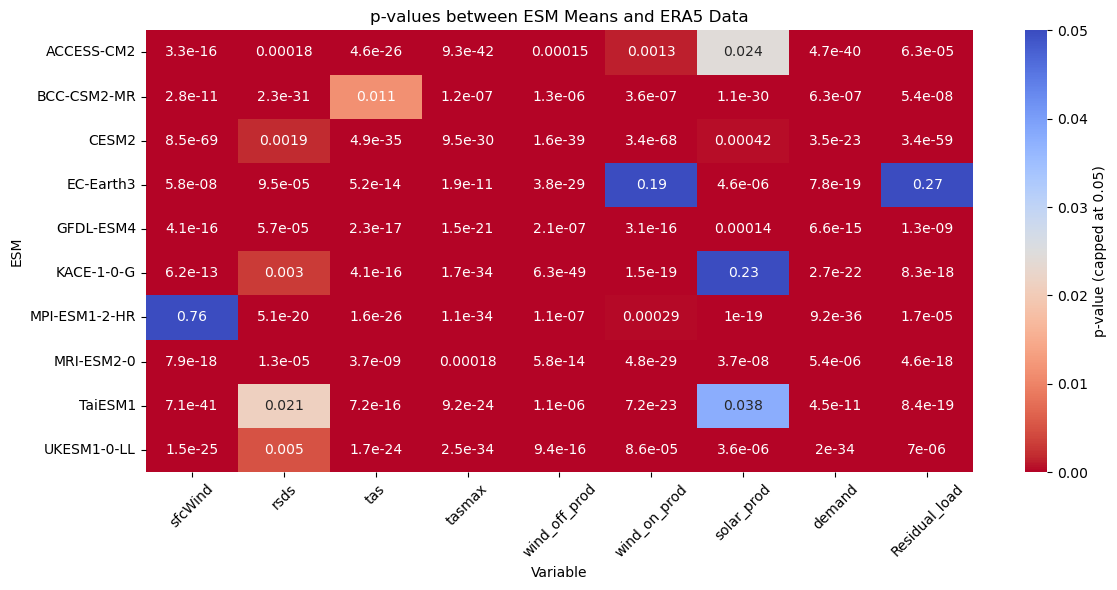

In [15]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(ts_winter[var].where(ts_winter['ESM'] == esm, drop=True).values.flatten(), ts_winter[var].where(ts_winter['ESM'] == 'ERA5_week', drop=True).values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'demand', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


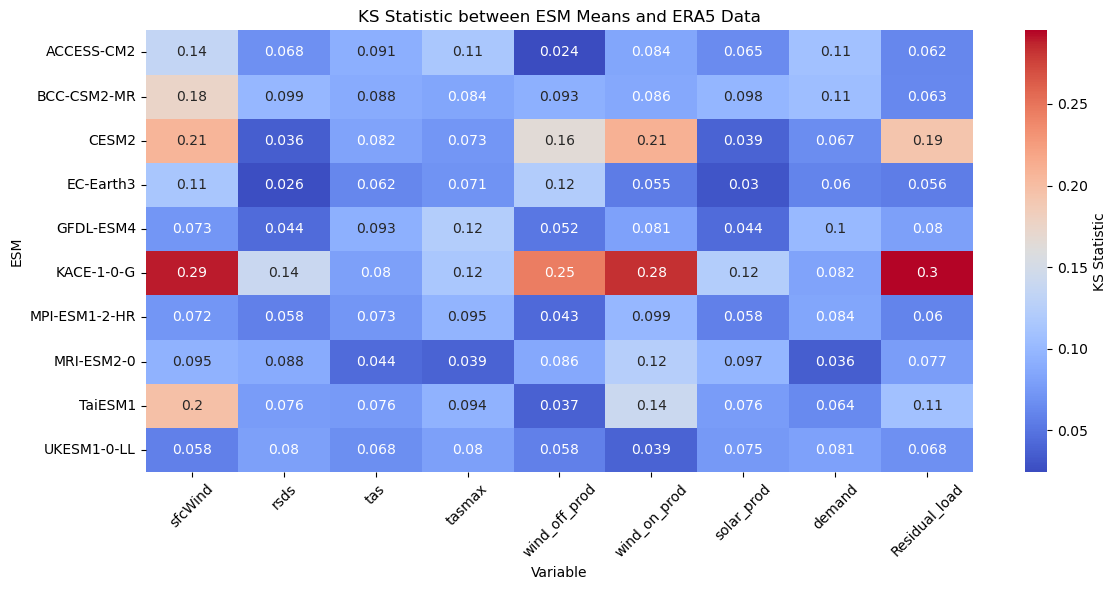

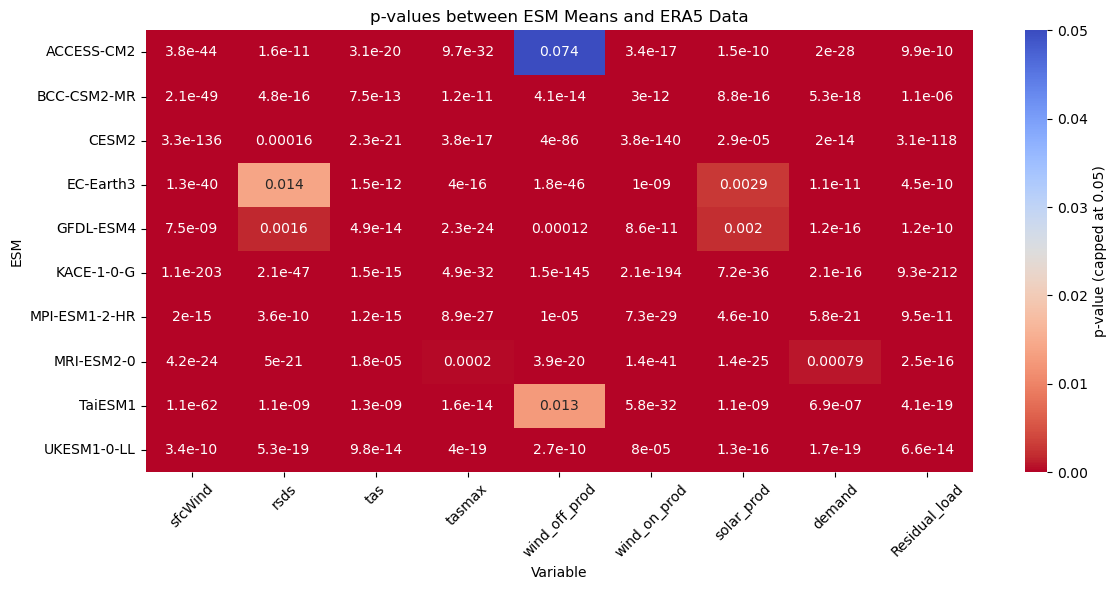

In [16]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(ts_datasets[var].where(ts_datasets['ESM'] == esm, drop=True).values.flatten(), ts_datasets[var].where(ts_datasets['ESM'] == 'ERA5_week', drop=True).values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'demand', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
esm_mean.ESM.values

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'ERA5_week',
       'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0',
       'TaiESM1', 'UKESM1-0-LL'], dtype=object)

In [11]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(esm_mean[var].sel(ESM=esm).values.flatten(), esm_mean[var].sel(ESM='ERA5_week').values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)
ks_df


,Variable,ESM,KS_stat,p_value
0,temp,ACCESS-CM2,0.134795,2.601461e-29
1,temp,BCC-CSM2-MR,0.097260,1.924441e-15
2,temp,CESM2,0.158082,3.360286e-40
3,temp,EC-Earth3,0.143014,5.924237e-33
4,temp,GFDL-ESM4,0.101096,1.187032e-16
...,...,...,...,...
95,Residual_load,KACE-1-0-G,0.372603,7.263274e-226
96,Residual_load,MPI-ESM1-2-HR,0.207397,4.256421e-69
97,Residual_load,MRI-ESM2-0,0.193425,4.241832e-60
98,Residual_load,TaiESM1,0.108493,4.056058e-19


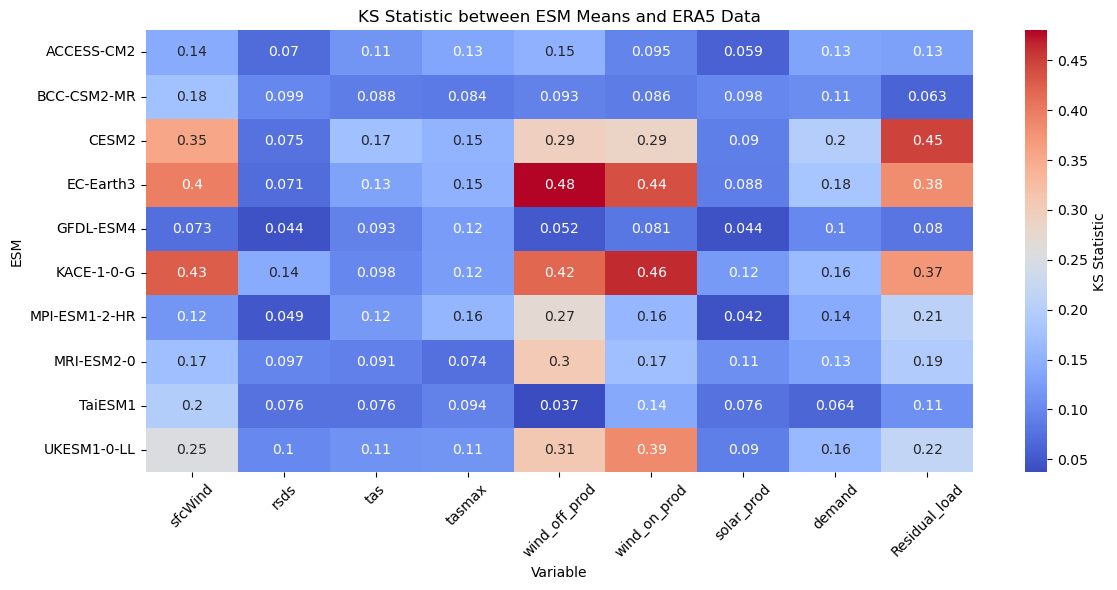

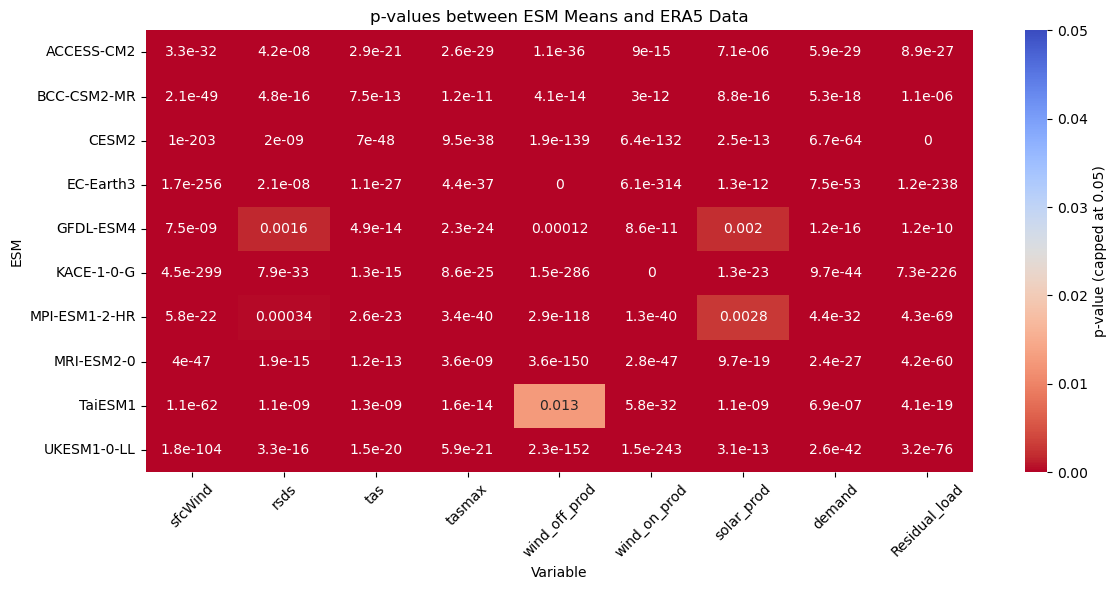

In [17]:
# Calculate the KS between the ESM means and the ERA5 data
ks_results = {}
esm_mean_vars = ['temp', 'demand', 'sfcWind', 'rsds', 'tas', 'tasmax', 'wind_off_prod', 'wind_on_prod', 'solar_prod', 'Residual_load']
for var in esm_mean_vars:
    for esm in esm_mean.ESM.values:
        if esm != 'ERA5_week':
            ks_stat, p_value = stats.ks_2samp(esm_mean[var].sel(ESM=esm).values.flatten(), esm_mean[var].sel(ESM='ERA5_week').values.flatten())
            ks_results[(var, esm)] = (ks_stat, p_value)

# Convert the results to a DataFrame for better visualization
ks_df = pd.DataFrame.from_dict(ks_results, orient='index', columns=['KS_stat', 'p_value'])
ks_df.index = pd.MultiIndex.from_tuples(ks_df.index, names=['Variable', 'ESM'])
ks_df.reset_index(inplace=True)

# Plot a heatmap of the KS statistics with the ESMs on the y-axis and the variables on the x-axis
ks_pivot = ks_df.pivot(index='ESM', columns='Variable', values='KS_stat')

variable_order = [
    'sfcWind', 'rsds', 'tas', 'tasmax',
    'wind_off_prod', 'wind_on_prod', 'solar_prod', 'demand', 'Residual_load'
]

# reorder columns safely (only keep those that exist)
ks_pivot = ks_pivot.reindex(columns=[v for v in variable_order if v in ks_pivot.columns])
plt.figure(figsize=(12, 6))
sns.heatmap(ks_pivot, annot=True, cmap='coolwarm', cbar_kws={'label': 'KS Statistic'})
plt.title('KS Statistic between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

ks_pivot_p = ks_df.pivot(index='ESM', columns='Variable', values='p_value')

# reorder columns safely (only keep those that exist)
ks_pivot_p = ks_pivot_p.reindex(columns=[v for v in variable_order if v in ks_pivot_p.columns])

# plt.figure(figsize=(12, 6))
# sns.heatmap(ks_pivot_p, annot=True, cmap='coolwarm', cbar_kws={'label': 'p-value'})
# plt.title('p-values between ESM Means and ERA5 Data')
# plt.ylabel('ESM')
# plt.xlabel('Variable')
# plt.xticks(rotation=45)
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

# Cap p-values at threshold
ks_pivot_p_plot = ks_pivot_p.clip(upper=p_thresh)

plt.figure(figsize=(12, 6))
sns.heatmap(
    ks_pivot_p_plot,
    annot=ks_pivot_p,
    # fmt=".2e",
    cmap='coolwarm_r',   # reversed
    vmin=0,
    vmax=p_thresh,
    cbar_kws={'label': f'p-value (capped at {p_thresh})'}
)

plt.title('p-values between ESM Means and ERA5 Data')
plt.ylabel('ESM')
plt.xlabel('Variable')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()